# **Model Input Data Validation & Exploration Notebook**

It is important we check the data before throwing it into the model so we can be confident the model is giving the best possible result. Here are some ways we can do this.

---

### **Correlation Matrix**
A correlation matrix will take every X variable (our indepdendants) and compare them on each other. It does a linear regression on each X vs X, and returns an r-score (aka the corellation/pearson coefficient) for every comparison.

Quick refresher on how an r-score is measured:
* **1 (Perfect Positive):** When one thing goes up, the other goes up.
* **-1 (Perfect Negative):** When one thing goes up, the other goes down.
* **0 (No Relationship):** They have nothing to do with each other.

In the heatmap below, colors closer to red show a strong positive relationship, while colors closer to blue show a strong negative relationship. Anything that is a faint white isn't really corellated.

This matrix is important to have to avoid a problem in ML called **"multicolinearity"**. This is when you have two variables that essentially do the same thing to the result. This is bad because the model will overweigh those inputs as a contribution, when they really should've been counted once. For example, if you looked at both # of seasons a player has played, and their age as two different features, that would most likely get double counted since players who have played many seasons, are inheritly older.

With the matrix you can make better decisions on what you want to do with your model input. Common actions would be to omit one of the variables, merge/avg the values, or add an additional context variable to differentiate them.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sqlite3

df = pd.read_csv('../../../db/model_input_v3.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../../../db/model_input_v3.csv'

In [3]:
# Quick formatting fix on the minutes col
def parse_minutes(m):
    if pd.isna(m):
        return m
    if isinstance(m, str) and ':' in m:
        parts = m.split(':')
        return int(parts[0]) + int(parts[1]) / 60
    return float(m)

df['minutes'] = df['minutes'].apply(parse_minutes)

# You only want quantifying variable in the matrix. 
# nothing like ids, categorical vars, or the target variables(s) 
exclude_cols = ['PLAYER_ID', 'game_id', 'is_injured']
x_vars = [col for col in df.columns if col not in exclude_cols]

This **corr** method below is where a lot of the magic happens.
Feel free to check documentation of it [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

In [5]:
# The corr() method is where the magic happens
corr_matrix = df[x_vars].corr()

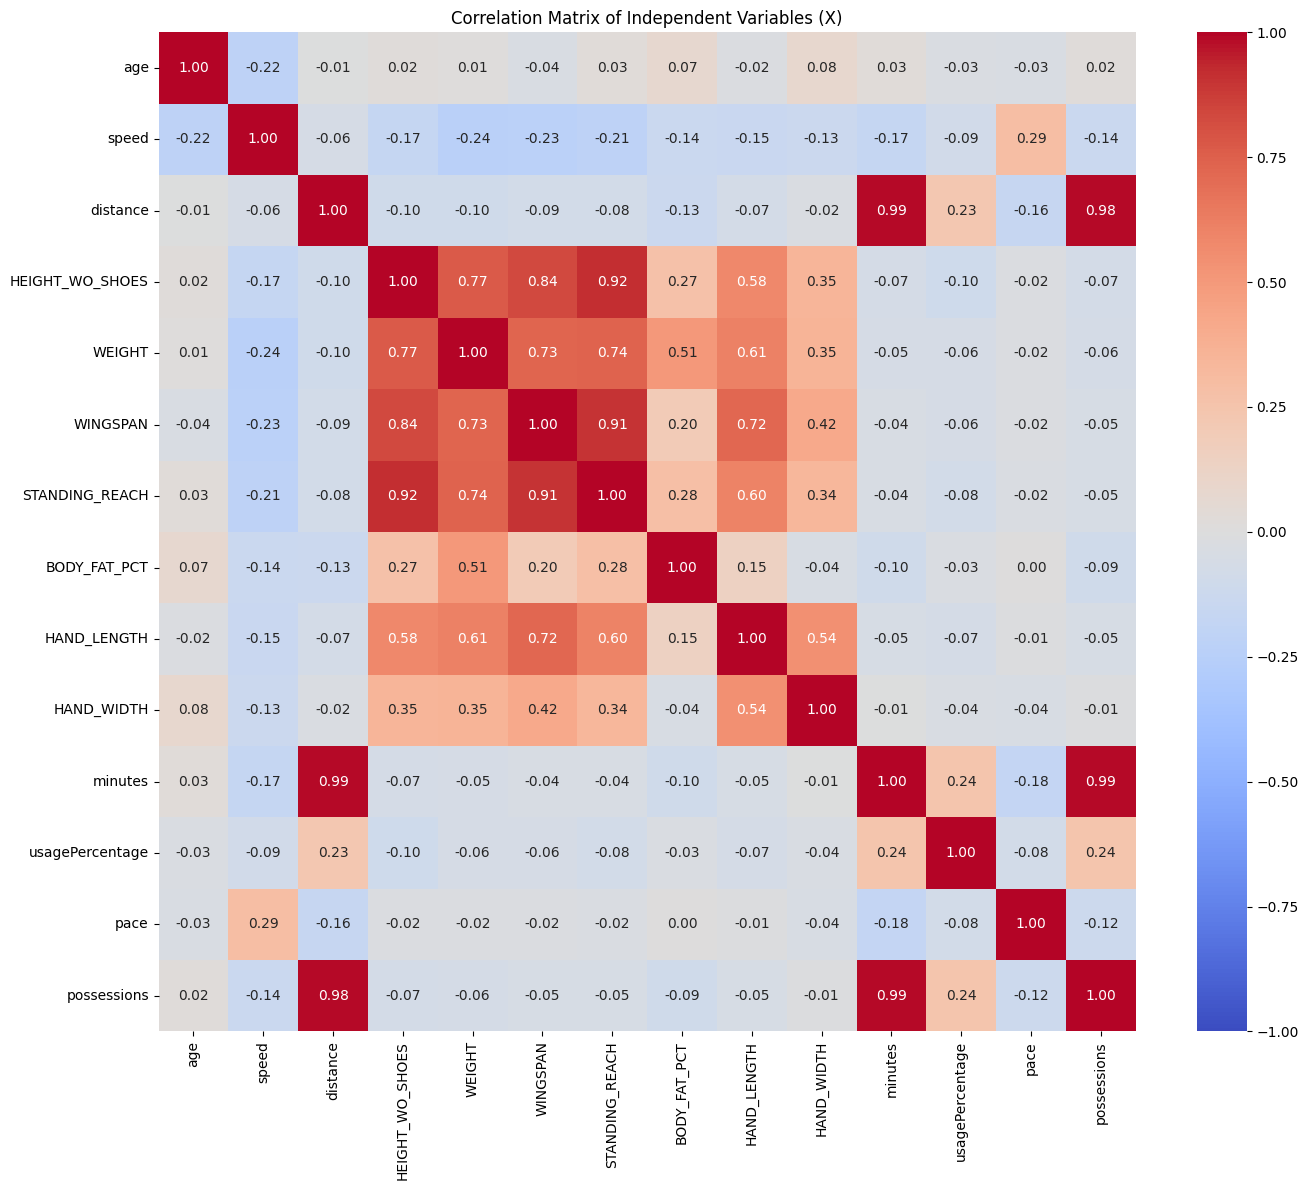

In [8]:
# Plot the correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Independent Variables (X)')
plt.tight_layout()
plt.show()

In [11]:
# Analyze highly correlated pairs

# Define what a "high" correlation is
threshold = 0.85
high_corr_pairs = []

cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= threshold:
            high_corr_pairs.append((cols[i], cols[j], val))

if high_corr_pairs:
    print(f"\nHighly correlated pairs with |correlation| >= {threshold}:")
    for var1, var2, corr_val in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {var1:25} <-> {var2:25} | r = {corr_val:.2f}")
else:
    print(f"\nNo variable pairs found with |correlation| >= {threshold}")


Highly correlated pairs with |correlation| >= 0.85:
  distance                  <-> minutes                   | r = 0.99
  minutes                   <-> possessions               | r = 0.99
  distance                  <-> possessions               | r = 0.98
  HEIGHT_WO_SHOES           <-> STANDING_REACH            | r = 0.92
  WINGSPAN                  <-> STANDING_REACH            | r = 0.91


Visually you can see a lot of the anthropometric variables have a higher corellation. This makes sense since people usually get proportionally larger, so nothing to worry about.

A trend that may raise concern is the distance, minutes, and possesions correlation. I would interpret this that the more a player plays the more they move, so there is no out of the ordinary distance they are travelling within a time span that would explain why they are getting injured.

### **Player Game-by-Game Trend Analysis**

The following cell allows you to configure top-level variables (`player_name` or `player_id`, `plot_vars`, and `date_range`) to visualize performance trends over an 82ish game season.

> **Note:** The selected variables plotted are **Min-Max Normalized (scaled from 0 to 1)** to allow completely different units (like distance in miles vs. speed in mph) to be visualized proportionally on the same axis without heavily distorting the graph. Scatter highlights indicate when the player was <span style="color:red">**Injured**</span> or took a <span style="color:grey">**Rest Day**</span>.

With this plot you can analyze if there are any trends of certain metrics or behaviours within a time window for a given player around an injury event.


In [1]:
# ==========================================
# Arguments
# ==========================================
player_id = None  # Example: 202694
player_name = "LeBron James"  # Provide player_id XOR player_name. If player_name is given, it fetches player_id.

# Uncomment the game stat variables you want to plot:
plot_vars = [
    'speed',
    'distance',
    # 'pace',
    'possessions',
    
    # *Minutes wont work right now, due to data type issues 
    # 'minutes',
    
    # 'usagePercentage'
]

# Date range (tuple). Use None for extreme bounds.
# Format: ('YYYY-MM-DD', 'YYYY-MM-DD')
date_range = (None, None) 

In [2]:

# ==========================================
# Data Loading & Processing
# ==========================================
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

db_path = "../../../db/BALL.db"
v4_csv_path = "./v4.csv"

conn = sqlite3.connect(db_path)

# Fetch player_id if player_name is provided
if player_name is not None:
    query = f"SELECT id FROM players WHERE full_name = '{player_name}'"
    pid_df = pd.read_sql(query, conn)
    if not pid_df.empty:
        player_id = pid_df.iloc[0]['id']
    else:
        print(f"Player '{player_name}' not found in database.")

# Load game dates to map game_id to chronological date
game_dates_df = pd.read_sql("SELECT game_id, game_date FROM game_dates", conn)
game_dates_df['game_id'] = game_dates_df['game_id'].astype(str)
game_dates_df['game_date'] = pd.to_datetime(game_dates_df['game_date'])
conn.close()

# Load EDA stats
df_v4 = pd.read_csv(v4_csv_path)
df_v4['game_id'] = df_v4['game_id'].astype(str)
df_v4['PLAYER_ID'] = df_v4['PLAYER_ID'].astype(str)
player_id = str(player_id)

# Merge stats with game dates
df_merged = pd.merge(df_v4, game_dates_df, on='game_id', how='left')

# Filter data for the chosen player
player_df = df_merged[df_merged['PLAYER_ID'] == player_id].copy()

# Apply Date Range Filtering if specified
if date_range[0] is not None:
    player_df = player_df[player_df['game_date'] >= pd.to_datetime(date_range[0])]
if date_range[1] is not None:
    player_df = player_df[player_df['game_date'] <= pd.to_datetime(date_range[1])]

# Sort chronologically to determine Game #
player_df = player_df.sort_values('game_date').reset_index(drop=True)
player_df['Game #'] = player_df.index + 1

if player_df.empty:
    print(f"No data found for the given arguments.")
else:
    # Feature Evaluation: Rest days are where speed/distance == 0. Injuries are where is_injured == 1
    player_df['is_rest_day'] = ((player_df['speed'] == 0) | (player_df['distance'] == 0)).astype(int)
    player_df['is_injury_day'] = player_df['is_injured']
    
    # Variables Calculation for Side Panel
    total_games_in_range = len(player_df)
    total_rest_days = player_df['is_rest_day'].sum()
    total_injuries = player_df['is_injury_day'].sum()
    averages_dict = {var: player_df[player_df['is_rest_day'] == 0][var].mean() for var in plot_vars if var in player_df.columns}
    
    # Normalize the chosen plot_vars explicitly between 0 and 1 so they fit beautifully on the same y-axis
    print("\n*** NOTE: The plot variables displayed have been MIN-MAX NORMALIZED to a 0 to 1 scale for visual comparison. ***\n")
    for var in plot_vars:
        if var in player_df.columns:
            # Calculate min and max ONLY on non-rest days so 0s don't skew the normalization
            min_val = player_df.loc[player_df['is_rest_day'] == 0, var].min()
            max_val = player_df.loc[player_df['is_rest_day'] == 0, var].max()
            if max_val != min_val and not np.isnan(min_val):
                player_df[f"{var}_norm"] = (player_df[var] - min_val) / (max_val - min_val)
            else:
                player_df[f"{var}_norm"] = 0
            # Turn rest days into NaNs for variables so the line plot breaks to show rest days
            player_df.loc[player_df['is_rest_day'] == 1, f"{var}_norm"] = np.nan

    # ==========================================
    # Plotting
    # ==========================================
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(16, 7))
    
    colors = sns.color_palette('husl', n_colors=len(plot_vars))
    
    # Plot Line graphs for normal games
    for idx, var in enumerate(plot_vars):
        norm_var = f"{var}_norm"
        if norm_var in player_df.columns:
            sns.lineplot(
                data=player_df, 
                x='Game #',
                y=norm_var,
                ax=ax,
                color=colors[idx],
                marker='o',
                linewidth=2,
                label=var.capitalize()
            )
            
    # Scatter highlights for Injuries
    injuries_df = player_df[player_df['is_injury_day'] == 1]
    if not injuries_df.empty:
        for norm_var in [f"{v}_norm" for v in plot_vars]:
            if norm_var in injuries_df.columns:
                ax.scatter(
                    x=injuries_df['Game #'], 
                    y=injuries_df[norm_var], 
                    color='red', 
                    s=200, 
                    zorder=10, 
                    edgecolors='white',
                    linewidth=1.5
                )
        for g in injuries_df['Game #']:
            ax.axvline(x=g, color='red', linestyle='--', alpha=0.7, zorder=0, linewidth=1.5)

    # Vertical lines for Rest Days
    rest_df = player_df[player_df['is_rest_day'] == 1]
    if not rest_df.empty:
        for g in rest_df['Game #']:
            ax.axvline(x=g, color='grey', linestyle='--', alpha=0.7, zorder=0, linewidth=1.5)

    # Side Panel for Aggregated Stats
    stats_text =  f"Time Range Stats:\n"
    stats_text += f"-----------------\n"
    stats_text += f"Games Total: {total_games_in_range}\n"
    stats_text += f"Injuries: {total_injuries}\n"
    stats_text += f"Rest Days: {total_rest_days}\n\n"
    stats_text += "Averages (Excl. Rest):\n"
    for var, avg in averages_dict.items():
        stats_text += f"{var}: {avg:.2f}\n"
        
    props = dict(boxstyle='round', facecolor='black', alpha=0.9, edgecolor='white')
    ax.text(1.02, 0.5, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='center', bbox=props, color='white')

    disp_name = player_name if player_name else player_id
    start_str = date_range[0] if date_range[0] else "Start"
    end_str = date_range[1] if date_range[1] else "End"
    plt.title(f'Game Trends for {disp_name} [{start_str} to {end_str}]', fontsize=18, pad=15, weight='bold')
    plt.xlabel('Game # (Chronological)', fontsize=14, labelpad=10)
    plt.ylabel('Normalized Value (0 to 1)', fontsize=14, labelpad=10)
    
    # Custom Legend
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=12, label='Injury Day'))
    handles.append(Line2D([0], [0], color='grey', linestyle='--', linewidth=1.5, label='Rest Day'))
    labels.extend(['Injury Day', 'Rest Day'])
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, frameon=True, edgecolor='white')

    # Remove top and right spines for aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()


DatabaseError: Execution failed on sql 'SELECT id FROM players WHERE full_name = 'LeBron James'': no such column: id